# DDoS Model Comparison with Hyperparameter Tuning (SetABC -> Holdout SetD)

Kulon notebook a tuningos benchmarkhoz ABC train pool + D holdout protokollal.

Folyamat:
- SetA + SetB + SetC osszefuzve: stratified train/validation/test
- Hyperparameter tuning minden modellre ABC validation alapon
- Vegso kierteseles: ABC test es SetD holdout
- Harom scenarioban:
  1. full SMOTE, class_weight nelkul
  2. partial SMOTE (csak DDoS attack osztalyra 0.15 aranyig) + class_weight
  3. nincs SMOTE, csak class_weight

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import re
import time
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    auc,
    precision_recall_fscore_support,
    )
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

print("Imports loaded.")

Imports loaded.


In [2]:
# Experiment config
DATA_DIR = Path("ddos-data-2024")
OUT_DIR = Path("ddos-detection/model_comparison_tuned_setABC_holdoutD")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_RECORDINGS = [
    "SCLDDoS2024_SetA",
    "SCLDDoS2024_SetB",
    "SCLDDoS2024_SetC",
]
HOLDOUT_RECORDING = "SCLDDoS2024_SetD"
TARGET_COL = "type"

TEST_SIZE = 0.20
VAL_SIZE = 0.10

MODEL_NAMES = ["logistic_regression", "random_forest", "boosting"]
SCENARIOS = [
    "smote_full_no_class_weight",
    "partial_smote_target_class_weight",
    "no_smote_class_weight",
]
TUNING_PRIMARY_METRIC = "f1_macro"

PARTIAL_SMOTE_TARGET_CLASS = "DDoS attack"
PARTIAL_SMOTE_TARGET_RATIO = 0.15

EVENTS_COLS = [
    "Attack ID", "Card", "Victim IP", "Port number", "Attack code", "Detect count",
    "Packet speed", "Data speed", "Avg packet len", "Avg source IP count",
    "Start time", "End time", "Type",
]

COMP_COLS = [
    "Attack ID", "Detect count", "Card", "Victim IP", "Port number", "Attack code",
    "Packet speed", "Data speed", "Avg packet len", "Source IP count", "Time",
]

print("Data dir:", DATA_DIR.resolve())
print("Output dir:", OUT_DIR.resolve())
print("Train recordings:", TRAIN_RECORDINGS)
print("Holdout recording:", HOLDOUT_RECORDING)
print("Scenarios:", SCENARIOS)

Data dir: /home/aron/ml/halado_adatelemzesi_modszerek/ddos-data-2024
Output dir: /home/aron/ml/halado_adatelemzesi_modszerek/ddos-detection/model_comparison_tuned_setABC_holdoutD
Train recordings: ['SCLDDoS2024_SetA', 'SCLDDoS2024_SetB', 'SCLDDoS2024_SetC']
Holdout recording: SCLDDoS2024_SetD
Scenarios: ['smote_full_no_class_weight', 'partial_smote_target_class_weight', 'no_smote_class_weight']


In [3]:
BOOSTING_BACKEND = "histgb"

try:
    from xgboost import XGBClassifier
    BOOSTING_BACKEND = "xgboost"
except Exception:
    try:
        from lightgbm import LGBMClassifier
        BOOSTING_BACKEND = "lightgbm"
    except Exception:
        BOOSTING_BACKEND = "histgb"

print(f"Boosting backend selected: {BOOSTING_BACKEND}")

Boosting backend selected: lightgbm


In [4]:
def _to_snake_case(name: str) -> str:
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")


def _safe_mode(series: pd.Series):
    vals = series.mode(dropna=True)
    return vals.iloc[0] if not vals.empty else np.nan


def preprocess_recordings(recordings, data_dir=DATA_DIR, verbose=True):
    events_frames = []
    comp_frames = []

    for recording in recordings:
        events_path = Path(data_dir) / f"{recording}_events.csv"
        comp_path = Path(data_dir) / f"{recording}_components.csv"

        if not events_path.exists() or not comp_path.exists():
            raise FileNotFoundError(f"Missing CSV for recording {recording} in {data_dir}")

        events = pd.read_csv(events_path, usecols=EVENTS_COLS)
        comps = pd.read_csv(comp_path, usecols=COMP_COLS)

        events["recording"] = recording
        comps["recording"] = recording

        events_frames.append(events)
        comp_frames.append(comps)

        if verbose:
            print(f"[load] {recording}: events={len(events)}, components={len(comps)}")

    events = pd.concat(events_frames, ignore_index=True)
    comps = pd.concat(comp_frames, ignore_index=True)

    if verbose:
        print(f"[combined] events={len(events)}, components={len(comps)}")

    events = events.drop_duplicates().copy()
    comps = comps.drop_duplicates().copy()

    events["Start time"] = pd.to_datetime(events["Start time"], errors="coerce")
    events["End time"] = pd.to_datetime(events["End time"], errors="coerce")
    comps["Time"] = pd.to_datetime(comps["Time"], errors="coerce")

    events = events.dropna(subset=["Attack ID", "Type", "Start time", "End time"]).copy()
    comps = comps.dropna(subset=["Attack ID", "Time"]).copy()

    events = events.loc[events["End time"] >= events["Start time"]].copy()

    valid_ids = set(events["Attack ID"].unique())
    comps = comps.loc[comps["Attack ID"].isin(valid_ids)].copy()

    events["event_duration_sec"] = (events["End time"] - events["Start time"]).dt.total_seconds()
    events["day_of_week"] = events["Start time"].dt.dayofweek
    events["hour_of_day"] = events["Start time"].dt.hour
    events["is_weekend"] = (events["day_of_week"] >= 5).astype(int)

    events["packet_data_ratio"] = events["Packet speed"] / (events["Data speed"].replace(0, np.nan))
    events["packet_data_ratio"] = events["packet_data_ratio"].replace([np.inf, -np.inf], np.nan)
    events["attack_intensity"] = events["Packet speed"] * events["Avg source IP count"]

    comp_agg = (
        comps.groupby("Attack ID", as_index=False)
        .agg(
            comp_row_count=("Detect count", "size"),
            comp_detect_count_max=("Detect count", "max"),
            comp_packet_speed_mean=("Packet speed", "mean"),
            comp_packet_speed_max=("Packet speed", "max"),
            comp_packet_speed_std=("Packet speed", "std"),
            comp_avg_packet_len_mean=("Avg packet len", "mean"),
            comp_source_ip_count_mean=("Source IP count", "mean"),
            comp_source_ip_count_max=("Source IP count", "max"),
            comp_attack_code_mode=("Attack code", _safe_mode),
            comp_card_mode=("Card", _safe_mode),
            comp_first_time=("Time", "min"),
            comp_last_time=("Time", "max"),
        )
        .copy()
    )

    comp_agg["comp_packet_speed_std"] = comp_agg["comp_packet_speed_std"].fillna(0)
    comp_agg["comp_duration_sec"] = (comp_agg["comp_last_time"] - comp_agg["comp_first_time"]).dt.total_seconds()
    comp_agg["source_ip_growth_rate"] = np.where(
        comp_agg["comp_duration_sec"] > 0,
        comp_agg["comp_source_ip_count_max"] / comp_agg["comp_duration_sec"],
        0.0,
    )

    events = events.sort_values("Start time").drop_duplicates(subset=["Attack ID"], keep="last").copy()
    merged = events.merge(comp_agg, on="Attack ID", how="left")

    merged = merged.drop(columns=["Victim IP", "Data speed"], errors="ignore")
    merged.columns = [_to_snake_case(c) for c in merged.columns]

    num_cols = merged.select_dtypes(include=["number"]).columns
    obj_cols = merged.select_dtypes(exclude=["number"]).columns
    merged[num_cols] = merged[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
    merged[obj_cols] = merged[obj_cols].fillna("missing")

    if verbose:
        print(f"[preprocess] rows={len(merged)}, cols={merged.shape[1]}")

    return merged

In [5]:
recordings_all = TRAIN_RECORDINGS + [HOLDOUT_RECORDING]
recording_frames = {}
for rec in recordings_all:
    recording_frames[rec] = preprocess_recordings([rec], data_dir=DATA_DIR, verbose=True)

abc_all = pd.concat([recording_frames[rec] for rec in TRAIN_RECORDINGS], ignore_index=True)
setd_holdout = recording_frames[HOLDOUT_RECORDING].copy()

def _safe_stratify(y: pd.Series):
    if y.nunique() <= 1:
        return None
    if y.value_counts().min() < 2:
        return None
    return y

strat = _safe_stratify(abc_all[TARGET_COL])
abc_train_val, abc_test = train_test_split(
    abc_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=strat,
 )

val_ratio_in_train_val = VAL_SIZE / (1.0 - TEST_SIZE)
strat_tv = _safe_stratify(abc_train_val[TARGET_COL])
abc_train, abc_val = train_test_split(
    abc_train_val,
    test_size=val_ratio_in_train_val,
    random_state=RANDOM_STATE,
    stratify=strat_tv,
 )

all_classes_union = np.array(
    sorted(
        pd.concat([abc_all[TARGET_COL], setd_holdout[TARGET_COL]], ignore_index=True).unique()
    )
)
train_classes = set(abc_all[TARGET_COL].unique())
holdout_extra_classes = sorted(set(setd_holdout[TARGET_COL].unique()) - train_classes)

print("ABC pool shape:", abc_all.shape)
print("- train:", abc_train.shape)
print("- val:", abc_val.shape)
print("- test:", abc_test.shape)
print("SetD holdout shape:", setd_holdout.shape)
print("Class universe (ABC + D):", all_classes_union.tolist())
if holdout_extra_classes:
    print("WARNING - Holdout has unseen classes not present in ABC train pool:", holdout_extra_classes)

print("\nABC train class distribution:")
display(abc_train[TARGET_COL].value_counts())
print("ABC validation class distribution:")
display(abc_val[TARGET_COL].value_counts())
print("ABC test class distribution:")
display(abc_test[TARGET_COL].value_counts())
print("SetD holdout class distribution:")
display(setd_holdout[TARGET_COL].value_counts())

[load] SCLDDoS2024_SetA: events=134770, components=586642
[combined] events=134770, components=586642
[preprocess] rows=134766, cols=32
[load] SCLDDoS2024_SetB: events=130000, components=1233449
[combined] events=130000, components=1233449
[preprocess] rows=130000, cols=32
[load] SCLDDoS2024_SetC: events=130000, components=1247266
[combined] events=130000, components=1247266
[preprocess] rows=129999, cols=32
[load] SCLDDoS2024_SetD: events=437657, components=2452610
[combined] events=437657, components=2452610
[preprocess] rows=437639, cols=32
ABC pool shape: (394765, 32)
- train: (276335, 32)
- val: (39477, 32)
- test: (78953, 32)
SetD holdout shape: (437639, 32)
Class universe (ABC + D): ['DDoS attack', 'Normal traffic', 'Suspicious traffic']

ABC train class distribution:


type
Normal traffic        262433
Suspicious traffic     11503
DDoS attack             2399
Name: count, dtype: int64

ABC validation class distribution:


type
Normal traffic        37491
Suspicious traffic     1643
DDoS attack             343
Name: count, dtype: int64

ABC test class distribution:


type
Normal traffic        74981
Suspicious traffic     3286
DDoS attack             686
Name: count, dtype: int64

SetD holdout class distribution:


type
Normal traffic        394482
Suspicious traffic     28424
DDoS attack            14733
Name: count, dtype: int64

In [6]:
LEAKAGE_DROP_COLS = [
    TARGET_COL,
    "attack_id",
    "recording",
    "start_time",
    "end_time",
    "comp_first_time",
    "comp_last_time",
    "attack_code",
    "comp_attack_code_mode",
]

def split_xy(df: pd.DataFrame, target_col: str = TARGET_COL):
    usable_drop = [c for c in LEAKAGE_DROP_COLS if c in df.columns]
    X = df.drop(columns=usable_drop).copy()
    y = df[target_col].copy()
    return X, y

def build_preprocessor(X_fit: pd.DataFrame):
    cat_cols = X_fit.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
    num_cols = X_fit.select_dtypes(include=["number"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                num_cols,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]),
                cat_cols,
            ),
        ],
        remainder="drop",
    )
    return preprocessor

def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

X_train_raw, y_train = split_xy(abc_train)
X_val_raw, y_val = split_xy(abc_val)
X_test_raw, y_test = split_xy(abc_test)
X_holdout_raw, y_holdout = split_xy(setd_holdout)

# Tuning encoding: fit only on ABC train
preprocessor_tune = build_preprocessor(X_train_raw)
X_train_tune = to_dense(preprocessor_tune.fit_transform(X_train_raw)).astype(np.float32)
X_val_tune = to_dense(preprocessor_tune.transform(X_val_raw)).astype(np.float32)

print("Tuning feature count:", len(preprocessor_tune.get_feature_names_out()))
print("Holdout transformed feature count check will use same preprocessor in final phase.")

Tuning feature count: 23
Holdout transformed feature count check will use same preprocessor in final phase.


In [7]:
def compute_multiclass_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }

def compute_prob_metrics(y_true, y_proba, class_labels):
    metrics = {}
    try:
        metrics["roc_auc_ovr_macro"] = roc_auc_score(
            y_true,
            y_proba,
            labels=class_labels,
            multi_class="ovr",
            average="macro",
        )
    except Exception:
        metrics["roc_auc_ovr_macro"] = np.nan

    y_bin = label_binarize(y_true, classes=class_labels)
    if y_bin.shape[1] == 1:
        metrics["pr_auc_macro"] = np.nan
    else:
        per_class_ap = []
        for i in range(y_bin.shape[1]):
            if y_bin[:, i].sum() == 0:
                continue
            per_class_ap.append(average_precision_score(y_bin[:, i], y_proba[:, i]))
        metrics["pr_auc_macro"] = float(np.mean(per_class_ap)) if per_class_ap else np.nan

    return metrics

def balanced_sample_weights(y: pd.Series) -> np.ndarray:
    classes = np.unique(y)
    class_w = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    class_map = dict(zip(classes, class_w))
    return y.map(class_map).values.astype(np.float32)

def class_ratio(y: pd.Series, class_name: str) -> float:
    if len(y) == 0:
        return 0.0
    return float((y == class_name).sum() / len(y))

def apply_smote_train_only(X_train_enc, y_train_series: pd.Series):
    class_counts = y_train_series.value_counts()
    min_count = int(class_counts.min())
    if min_count < 2:
        raise ValueError("SMOTE requires at least 2 samples in the smallest class.")

    k_neighbors = min(5, min_count - 1)
    smote = SMOTE(
        random_state=RANDOM_STATE,
        k_neighbors=k_neighbors,
        sampling_strategy="not majority",
    )
    X_res, y_res = smote.fit_resample(X_train_enc, y_train_series)
    return X_res, pd.Series(y_res)

def apply_partial_smote_target_class(
    X_train_enc,
    y_train_series: pd.Series,
    target_class: str,
    target_ratio: float = 0.15,
 ):
    y_train_series = y_train_series.reset_index(drop=True)
    current_count = int((y_train_series == target_class).sum())
    target_count = int(math.ceil(target_ratio * len(y_train_series)))

    if target_count <= current_count:
        return X_train_enc, y_train_series, False, current_count, current_count

    if current_count < 2:
        raise ValueError(
            f"Partial SMOTE cannot run for class {target_class}: current_count={current_count} < 2"
        )

    k_neighbors = min(5, current_count - 1)
    smote = SMOTE(
        random_state=RANDOM_STATE,
        k_neighbors=k_neighbors,
        sampling_strategy={target_class: target_count},
    )
    X_res, y_res = smote.fit_resample(X_train_enc, y_train_series)
    new_count = int((np.asarray(y_res) == target_class).sum())
    return X_res, pd.Series(y_res), True, current_count, new_count

def align_proba_columns(model, y_proba, class_labels):
    aligned = pd.DataFrame(y_proba, columns=model.classes_)
    aligned = aligned.reindex(columns=class_labels, fill_value=0.0)
    return aligned.values

def build_ovr_curve_rows(y_true, y_proba, class_labels, model_name: str, scenario: str, dataset_name: str):
    rows = []
    y_bin = label_binarize(y_true, classes=class_labels)
    if y_bin.ndim == 1:
        y_bin = y_bin.reshape(-1, 1)

    for idx, class_name in enumerate(class_labels):
        if idx >= y_bin.shape[1]:
            continue
        y_class = y_bin[:, idx]
        if y_class.sum() == 0 or y_class.sum() == len(y_class):
            continue

        fpr, tpr, _ = roc_curve(y_class, y_proba[:, idx])
        precision, recall, _ = precision_recall_curve(y_class, y_proba[:, idx])
        rows.append({
            "model": model_name,
            "scenario": scenario,
            "dataset": dataset_name,
            "class_name": class_name,
            "roc_auc": float(auc(fpr, tpr)),
            "pr_auc": float(auc(recall, precision)),
            "avg_precision": float(average_precision_score(y_class, y_proba[:, idx])),
        })

    return rows

def expand_param_grid(grid_dict):
    keys = list(grid_dict.keys())
    values = [grid_dict[k] for k in keys]
    combos = []
    for vals in product(*values):
        combos.append(dict(zip(keys, vals)))
    return combos

def get_param_grid(model_name: str, backend: str):
    if model_name == "logistic_regression":
        return expand_param_grid({
            "C": [0.2, 1.0, 4.0],
            "max_iter": [2500],
        })

    if model_name == "random_forest":
        return expand_param_grid({
            "n_estimators": [250, 400],
            "max_depth": [14, 22],
            "min_samples_leaf": [1, 2],
        })

    if model_name == "boosting":
        if backend == "xgboost":
            return expand_param_grid({
                "n_estimators": [250, 400],
                "max_depth": [6, 8],
                "learning_rate": [0.05, 0.1],
            })

        if backend == "lightgbm":
            return expand_param_grid({
                "n_estimators": [250, 400],
                "learning_rate": [0.05, 0.1],
                "num_leaves": [31, 63],
            })

        return expand_param_grid({
            "max_iter": [250, 400],
            "max_depth": [8, 12],
            "learning_rate": [0.05, 0.1],
        })

    raise ValueError(f"Unknown model_name: {model_name}")

def make_model(model_name: str, use_class_weight: bool, params: dict):
    if model_name == "logistic_regression":
        return LogisticRegression(
            solver="lbfgs",
            class_weight=("balanced" if use_class_weight else None),
            random_state=RANDOM_STATE,
            **params,
        )

    if model_name == "random_forest":
        return RandomForestClassifier(
            class_weight=("balanced_subsample" if use_class_weight else None),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            **params,
        )

    if model_name == "boosting":
        if BOOSTING_BACKEND == "xgboost":
            return XGBClassifier(
                objective="multi:softprob",
                eval_metric="mlogloss",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **params,
            )

        if BOOSTING_BACKEND == "lightgbm":
            return LGBMClassifier(
                objective="multiclass",
                class_weight=("balanced" if use_class_weight else None),
                random_state=RANDOM_STATE,
                **params,
            )

        return HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            **params,
        )

    raise ValueError(f"Unknown model_name: {model_name}")

In [8]:
def tune_model_on_validation(model_name: str, scenario: str):
    if scenario not in SCENARIOS:
        raise ValueError(f"Unknown scenario: {scenario}")

    if scenario == "smote_full_no_class_weight":
        use_class_weight = False
    else:
        use_class_weight = True

    param_grid = get_param_grid(model_name, BOOSTING_BACKEND)
    tuning_rows = []

    for idx, params in enumerate(param_grid, start=1):
        partial_applied = False
        target_before = class_ratio(y_train, PARTIAL_SMOTE_TARGET_CLASS)
        target_after = target_before

        if scenario == "smote_full_no_class_weight":
            X_fit, y_fit = apply_smote_train_only(X_train_tune, y_train)
        elif scenario == "partial_smote_target_class_weight":
            X_fit, y_fit, partial_applied, old_count, new_count = apply_partial_smote_target_class(
                X_train_tune,
                y_train,
                target_class=PARTIAL_SMOTE_TARGET_CLASS,
                target_ratio=PARTIAL_SMOTE_TARGET_RATIO,
            )
            target_before = old_count / len(y_train)
            target_after = new_count / len(y_fit)
        else:
            X_fit, y_fit = X_train_tune, y_train

        model = make_model(model_name, use_class_weight=use_class_weight, params=params)

        fit_kwargs = {}
        if use_class_weight and model_name == "boosting" and BOOSTING_BACKEND in {"xgboost", "histgb"}:
            fit_kwargs["sample_weight"] = balanced_sample_weights(y_fit)

        t0 = time.perf_counter()
        model.fit(X_fit, y_fit, **fit_kwargs)
        fit_time = time.perf_counter() - t0

        pred_val = model.predict(X_val_tune)
        val_metrics = compute_multiclass_metrics(y_val, pred_val)

        tuning_rows.append({
            "model": model_name,
            "scenario": scenario,
            "candidate_idx": idx,
            "params": json.dumps(params, sort_keys=True),
            **val_metrics,
            "fit_time_sec": fit_time,
            "target_class": PARTIAL_SMOTE_TARGET_CLASS,
            "target_ratio_before": float(target_before),
            "target_ratio_after": float(target_after),
            "partial_smote_applied": bool(partial_applied),
        })

    tuning_df_local = pd.DataFrame(tuning_rows)
    tuning_df_local = tuning_df_local.sort_values(
        ["f1_macro", "balanced_accuracy", "accuracy"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    best_row = tuning_df_local.iloc[0].copy()
    best_params = json.loads(best_row["params"])
    return best_params, tuning_df_local

all_tuning_rows = []
best_params_map = {}

for model_name in MODEL_NAMES:
    for scenario in SCENARIOS:
        print(f"Tuning {model_name} / {scenario}")
        best_params, tuning_table = tune_model_on_validation(model_name, scenario)
        best_params_map[(model_name, scenario)] = best_params
        all_tuning_rows.append(tuning_table)

tuning_results_df = pd.concat(all_tuning_rows, ignore_index=True)
display(tuning_results_df.head(20))

print("Best params per model/scenario:")
for key, params in best_params_map.items():
    print(f"- {key}: {params}")

Tuning logistic_regression / smote_full_no_class_weight
Tuning logistic_regression / partial_smote_target_class_weight
Tuning logistic_regression / no_smote_class_weight
Tuning random_forest / smote_full_no_class_weight
Tuning random_forest / partial_smote_target_class_weight
Tuning random_forest / no_smote_class_weight
Tuning boosting / smote_full_no_class_weight
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010151 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5355
[LightGBM] [Info] Number of data points in the train set: 787299, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] T

,model,scenario,candidate_idx,params,accuracy,balanced_accuracy,f1_macro,fit_time_sec,target_class,target_ratio_before,target_ratio_after,partial_smote_applied
0,logistic_regression,smote_full_no_class_weight,2,"{""C"": 1.0, ""max_iter"": 2500}",0.737974,0.743055,0.418330,42.103162,DDoS attack,0.008681,0.008681,False
1,logistic_regression,smote_full_no_class_weight,1,"{""C"": 0.2, ""max_iter"": 2500}",0.740026,0.736848,0.417433,28.517399,DDoS attack,0.008681,0.008681,False
2,logistic_regression,smote_full_no_class_weight,3,"{""C"": 4.0, ""max_iter"": 2500}",0.736530,0.744086,0.417060,29.917066,DDoS attack,0.008681,0.008681,False
3,logistic_regression,partial_smote_target_class_weight,3,"{""C"": 4.0, ""max_iter"": 2500}",0.739469,0.733763,0.417132,17.226503,DDoS attack,0.008681,0.131429,True
4,logistic_regression,partial_smote_target_class_weight,2,"{""C"": 1.0, ""max_iter"": 2500}",0.738683,0.733301,0.416252,13.236196,DDoS attack,0.008681,0.131429,True
5,logistic_regression,partial_smote_target_class_weight,1,"{""C"": 0.2, ""max_iter"": 2500}",0.735112,0.729927,0.412759,8.865174,DDoS attack,0.008681,0.131429,True
6,logistic_regression,no_smote_class_weight,2,"{""C"": 1.0, ""max_iter"": 2500}",0.742458,0.730968,0.417474,9.010037,DDoS attack,0.008681,0.008681,False
7,logistic_regression,no_smote_class_weight,3,"{""C"": 4.0, ""max_iter"": 2500}",0.737442,0.728050,0.414258,14.128342,DDoS attack,0.008681,0.008681,False
8,logistic_regression,no_smote_class_weight,1,"{""C"": 0.2, ""max_iter"": 2500}",0.737315,0.728969,0.413806,8.398148,DDoS attack,0.008681,0.008681,False
9,random_forest,smote_full_no_class_weight,3,"{""max_depth"": 22, ""min_samples_leaf"": 1, ""n_es...",0.972440,0.891573,0.830370,30.195983,DDoS attack,0.008681,0.008681,False


Best params per model/scenario:
- ('logistic_regression', 'smote_full_no_class_weight'): {'C': 1.0, 'max_iter': 2500}
- ('logistic_regression', 'partial_smote_target_class_weight'): {'C': 4.0, 'max_iter': 2500}
- ('logistic_regression', 'no_smote_class_weight'): {'C': 1.0, 'max_iter': 2500}
- ('random_forest', 'smote_full_no_class_weight'): {'max_depth': 22, 'min_samples_leaf': 1, 'n_estimators': 250}
- ('random_forest', 'partial_smote_target_class_weight'): {'max_depth': 22, 'min_samples_leaf': 1, 'n_estimators': 400}
- ('random_forest', 'no_smote_class_weight'): {'max_depth': 22, 'min_samples_leaf': 2, 'n_estimators': 250}
- ('boosting', 'smote_full_no_class_weight'): {'learning_rate': 0.1, 'n_estimators': 400, 'num_leaves': 63}
- ('boosting', 'partial_smote_target_class_weight'): {'learning_rate': 0.1, 'n_estimators': 400, 'num_leaves': 63}
- ('boosting', 'no_smote_class_weight'): {'learning_rate': 0.1, 'n_estimators': 400, 'num_leaves': 63}


In [9]:
# Final comparison protocol with tuned hyperparameters
X_train_val_raw = pd.concat([X_train_raw, X_val_raw], ignore_index=True)
y_train_val = pd.concat([y_train.reset_index(drop=True), y_val.reset_index(drop=True)], ignore_index=True)
CLASS_LABELS_TRAIN = np.array(sorted(y_train_val.unique()))

preprocessor_final = build_preprocessor(X_train_val_raw)
X_train_val_enc = to_dense(preprocessor_final.fit_transform(X_train_val_raw)).astype(np.float32)
X_test_enc = to_dense(preprocessor_final.transform(X_test_raw)).astype(np.float32)
X_holdout_enc = to_dense(preprocessor_final.transform(X_holdout_raw)).astype(np.float32)

final_rows = []
per_class_rows = []
roc_pr_rows = []
final_predictions = {}
final_models = {}

eval_sets = [
    ("abc_test", y_test, X_test_enc),
    ("setd_holdout", y_holdout, X_holdout_enc),
]

for model_name in MODEL_NAMES:
    for scenario in SCENARIOS:
        params = best_params_map[(model_name, scenario)]
        use_class_weight = scenario != "smote_full_no_class_weight"

        partial_applied = False
        partial_ratio_before = class_ratio(y_train_val, PARTIAL_SMOTE_TARGET_CLASS)
        partial_ratio_after = partial_ratio_before

        if scenario == "smote_full_no_class_weight":
            X_fit, y_fit = apply_smote_train_only(X_train_val_enc, y_train_val)
        elif scenario == "partial_smote_target_class_weight":
            X_fit, y_fit, partial_applied, old_count, new_count = apply_partial_smote_target_class(
                X_train_val_enc,
                y_train_val,
                target_class=PARTIAL_SMOTE_TARGET_CLASS,
                target_ratio=PARTIAL_SMOTE_TARGET_RATIO,
            )
            partial_ratio_before = old_count / len(y_train_val)
            partial_ratio_after = new_count / len(y_fit)
        else:
            X_fit, y_fit = X_train_val_enc, y_train_val

        model = make_model(model_name, use_class_weight=use_class_weight, params=params)
        fit_kwargs = {}
        if use_class_weight and model_name == "boosting" and BOOSTING_BACKEND in {"xgboost", "histgb"}:
            fit_kwargs["sample_weight"] = balanced_sample_weights(y_fit)

        t0 = time.perf_counter()
        model.fit(X_fit, y_fit, **fit_kwargs)
        fit_time = time.perf_counter() - t0

        t1 = time.perf_counter()
        pred_by_dataset = {}
        for dataset_name, y_true, X_eval in eval_sets:
            pred = model.predict(X_eval)
            if hasattr(model, "predict_proba"):
                y_proba_raw = model.predict_proba(X_eval)
            else:
                y_proba_raw = np.zeros((len(X_eval), len(model.classes_)), dtype=np.float32)

            y_proba = align_proba_columns(model, y_proba_raw, CLASS_LABELS_TRAIN)
            met = compute_multiclass_metrics(y_true, pred)

            known_mask = pd.Series(y_true).isin(CLASS_LABELS_TRAIN).values
            if known_mask.sum() >= 2 and len(np.unique(np.asarray(y_true)[known_mask])) > 1:
                met_prob = compute_prob_metrics(
                    np.asarray(y_true)[known_mask],
                    y_proba[known_mask],
                    CLASS_LABELS_TRAIN,
                )
                roc_pr_rows.extend(
                    build_ovr_curve_rows(
                        np.asarray(y_true)[known_mask],
                        y_proba[known_mask],
                        CLASS_LABELS_TRAIN,
                        model_name=model_name,
                        scenario=scenario,
                        dataset_name=dataset_name,
                    )
                )
            else:
                met_prob = {"roc_auc_ovr_macro": np.nan, "pr_auc_macro": np.nan}

            final_rows.append({
                "model": model_name,
                "scenario": scenario,
                "dataset": dataset_name,
                **met,
                **met_prob,
                "fit_time_sec": fit_time,
                "best_params": json.dumps(params, sort_keys=True),
                "target_class": PARTIAL_SMOTE_TARGET_CLASS,
                "target_ratio_before": float(partial_ratio_before),
                "target_ratio_after": float(partial_ratio_after),
                "partial_smote_applied": bool(partial_applied),
            })

            p_arr, r_arr, f_arr, s_arr = precision_recall_fscore_support(
                y_true,
                pred,
                labels=CLASS_LABELS_TRAIN,
                zero_division=0,
            )
            for cls_name, p_val, r_val, f_val, s_val in zip(CLASS_LABELS_TRAIN, p_arr, r_arr, f_arr, s_arr):
                per_class_rows.append({
                    "model": model_name,
                    "scenario": scenario,
                    "dataset": dataset_name,
                    "class_name": cls_name,
                    "precision": float(p_val),
                    "recall": float(r_val),
                    "f1": float(f_val),
                    "support": int(s_val),
                })

            pred_by_dataset[dataset_name] = {
                "y_true": np.asarray(y_true),
                "y_pred": np.asarray(pred),
                "y_proba": y_proba,
            }

        predict_time = time.perf_counter() - t1
        for row in final_rows[-len(eval_sets):]:
            row["predict_time_sec"] = predict_time

        final_models[(model_name, scenario)] = model
        final_predictions[(model_name, scenario)] = pred_by_dataset

final_results_df = pd.DataFrame(final_rows)
final_results_df = final_results_df.sort_values(
    ["dataset", "f1_macro", "balanced_accuracy", "accuracy"],
    ascending=[True, False, False, False],
).reset_index(drop=True)
per_class_metrics_df = pd.DataFrame(per_class_rows)
roc_pr_df = pd.DataFrame(roc_pr_rows)

print("Tuned final comparison (ABC test + SetD holdout):")
display(final_results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011092 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5355
[LightGBM] [Info] Number of data points in the train set: 899772, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001671 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5350
[LightGBM] [Info] Number of data points in the train set: 360442, number of used features: 21
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Auto-choosing 

,model,scenario,dataset,accuracy,balanced_accuracy,f1_macro,roc_auc_ovr_macro,pr_auc_macro,fit_time_sec,best_params,target_class,target_ratio_before,target_ratio_after,partial_smote_applied,predict_time_sec
0,boosting,smote_full_no_class_weight,abc_test,0.982509,0.864253,0.870257,0.987728,0.915987,9.719660,"{""learning_rate"": 0.1, ""n_estimators"": 400, ""n...",DDoS attack,0.008682,0.008682,False,7.961867
1,boosting,partial_smote_target_class_weight,abc_test,0.979317,0.893817,0.865193,0.988596,0.919675,4.876885,"{""learning_rate"": 0.1, ""n_estimators"": 400, ""n...",DDoS attack,0.008682,0.131428,True,7.923606
2,boosting,no_smote_class_weight,abc_test,0.978342,0.900323,0.856865,0.986160,0.916509,3.792504,"{""learning_rate"": 0.1, ""n_estimators"": 400, ""n...",DDoS attack,0.008682,0.008682,False,7.964680
3,random_forest,no_smote_class_weight,abc_test,0.975276,0.871391,0.847229,0.984437,0.900223,10.845970,"{""max_depth"": 22, ""min_samples_leaf"": 2, ""n_es...",DDoS attack,0.008682,0.008682,False,4.557894
4,random_forest,partial_smote_target_class_weight,abc_test,0.975454,0.883552,0.843216,0.986743,0.899511,19.514662,"{""max_depth"": 22, ""min_samples_leaf"": 1, ""n_es...",DDoS attack,0.008682,0.131428,True,5.367878
5,random_forest,smote_full_no_class_weight,abc_test,0.974162,0.892212,0.837075,0.985663,0.900786,36.024699,"{""max_depth"": 22, ""min_samples_leaf"": 1, ""n_es...",DDoS attack,0.008682,0.008682,False,4.690075
6,logistic_regression,partial_smote_target_class_weight,abc_test,0.737882,0.730654,0.417321,0.880935,0.560853,16.293267,"{""C"": 4.0, ""max_iter"": 2500}",DDoS attack,0.008682,0.131428,True,3.711604
7,logistic_regression,smote_full_no_class_weight,abc_test,0.735134,0.736596,0.415229,0.880072,0.559407,18.345777,"{""C"": 1.0, ""max_iter"": 2500}",DDoS attack,0.008682,0.008682,False,3.621758
8,logistic_regression,no_smote_class_weight,abc_test,0.736919,0.727226,0.414256,0.879588,0.549131,11.027880,"{""C"": 1.0, ""max_iter"": 2500}",DDoS attack,0.008682,0.008682,False,3.629870
9,boosting,partial_smote_target_class_weight,setd_holdout,0.919210,0.618125,0.668379,0.933118,0.723224,4.876885,"{""learning_rate"": 0.1, ""n_estimators"": 400, ""n...",DDoS attack,0.008682,0.131428,True,7.923606


accuracy              balanced_accuracy               f1_macro              pr_auc_macro              roc_auc_ovr_macro             
dataset                                                abc_test setd_holdout          abc_test setd_holdout  abc_test setd_holdout     abc_test setd_holdout          abc_test setd_holdout
model               scenario                                                                                                                                                               
boosting            no_smote_class_weight              0.978342     0.918979          0.900323     0.613639  0.856865     0.662033     0.916509     0.704291          0.986160     0.924575
                    partial_smote_target_class_weight  0.979317     0.919210          0.893817     0.618125  0.865193     0.668379     0.919675     0.723224          0.988596     0.933118
                    smote_full_no_class_weight         0.982509     0.920759          0.864253     0.580951  0.870257     0.638579     0.915987     0.740787          0.987728     0.952906
logistic_regression no_smote_class_weight              0.736919     0.241372          0.727226     0.398402  0.414256     0.259295     0.549131     0.482384          0.879588     0.745620
                    partial_smote_target_class_weight  0.737882     0.246765          0.730654     0.408588  0.417321     0.266427     0.560853     0.487362          0.880935     0.747930
                    smote_full_no_class_weight         0.735134     0.191148          0.736596     0.398600  0.415229     0.240438     0.559407     0.486241          0.880072     0.743135
random_forest       no_smote_class_weight              0.975276     0.908032          0.871391     0.545774  0.847229     0.594968     0.900223     0.730306          0.984437     0.966364
                    partial_smote_target_class_weight  0.975454     0.909012          0.883552     0.552514  0.843216     0.576098     0.899511     0.732852          0.986743     0.963112
                    smote_full_no_class_weight         0.974162     0.919911          0.892212     0.630573  0.837075     0.659048     0.900786     0.742711          0.985663     0.967163

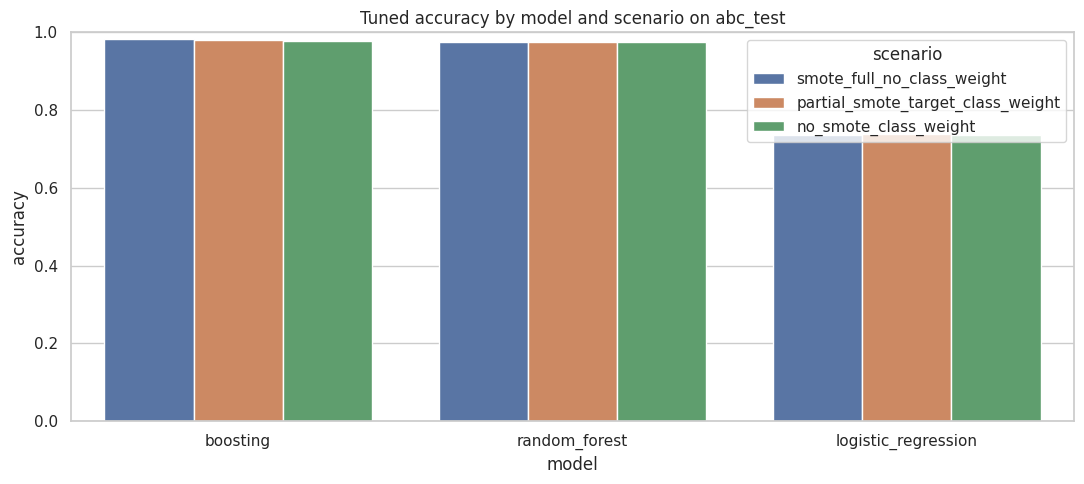

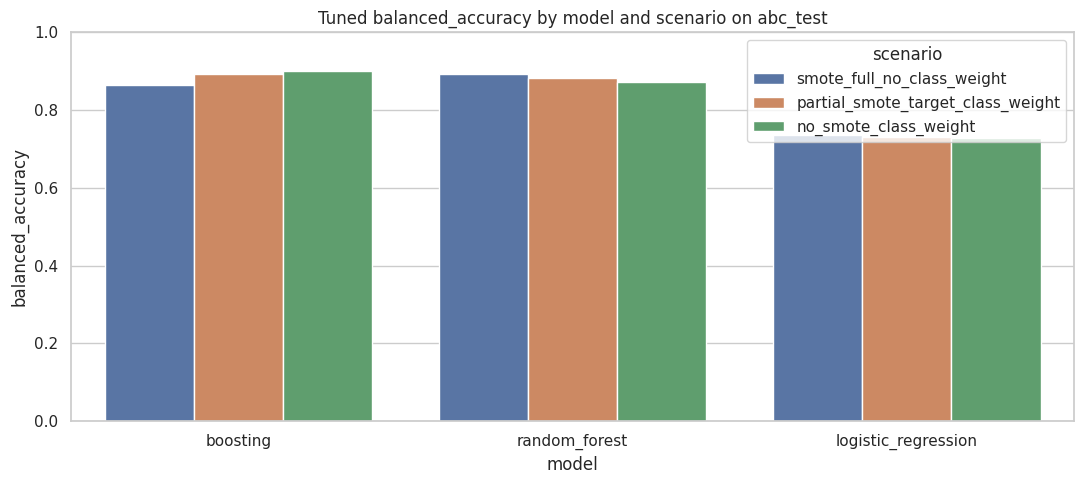

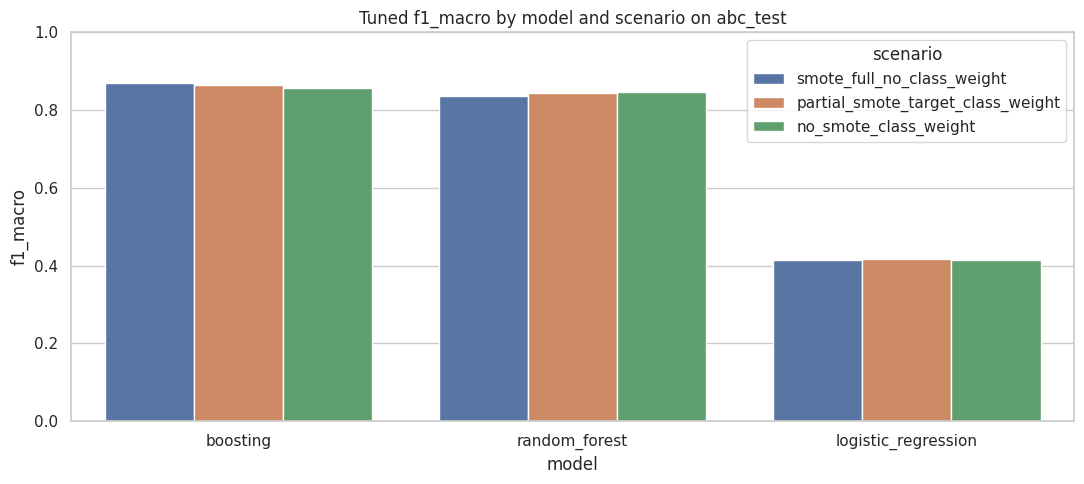

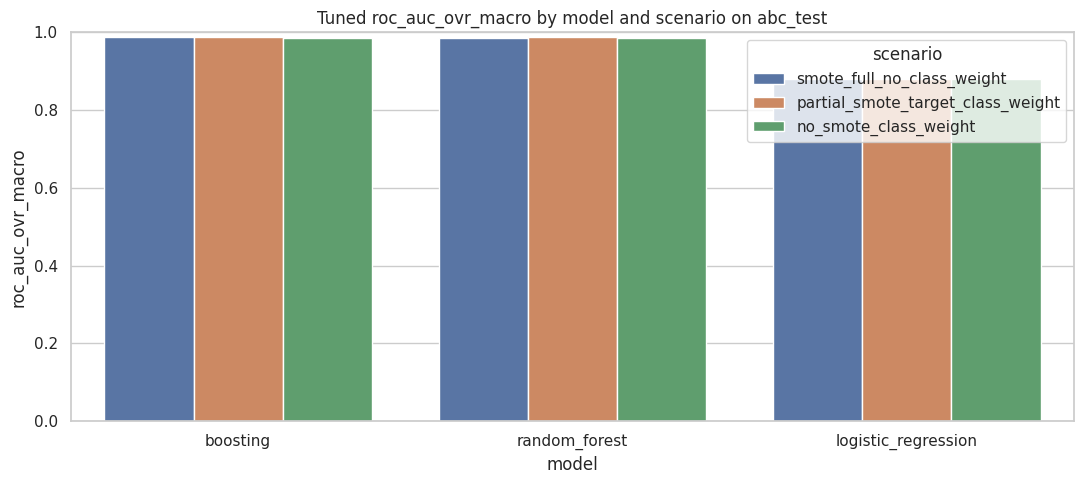

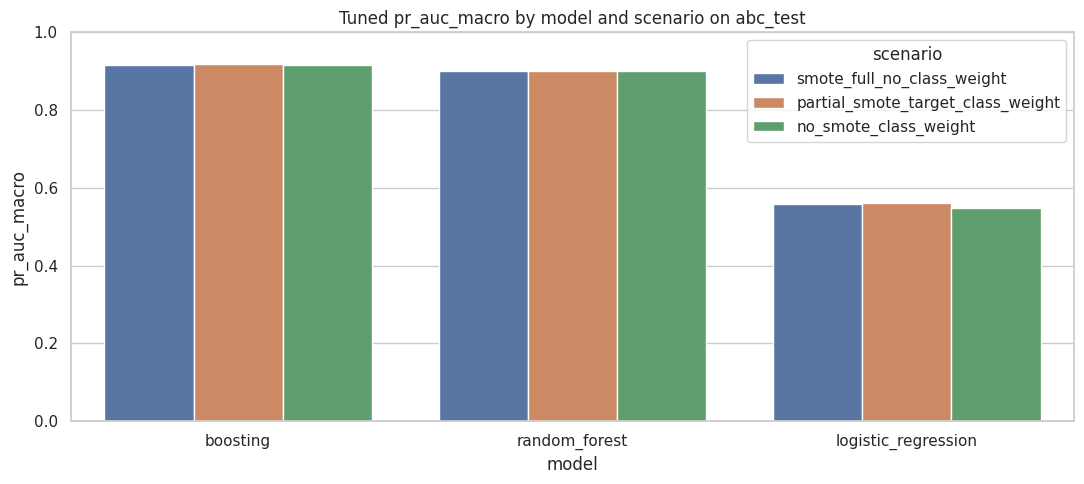

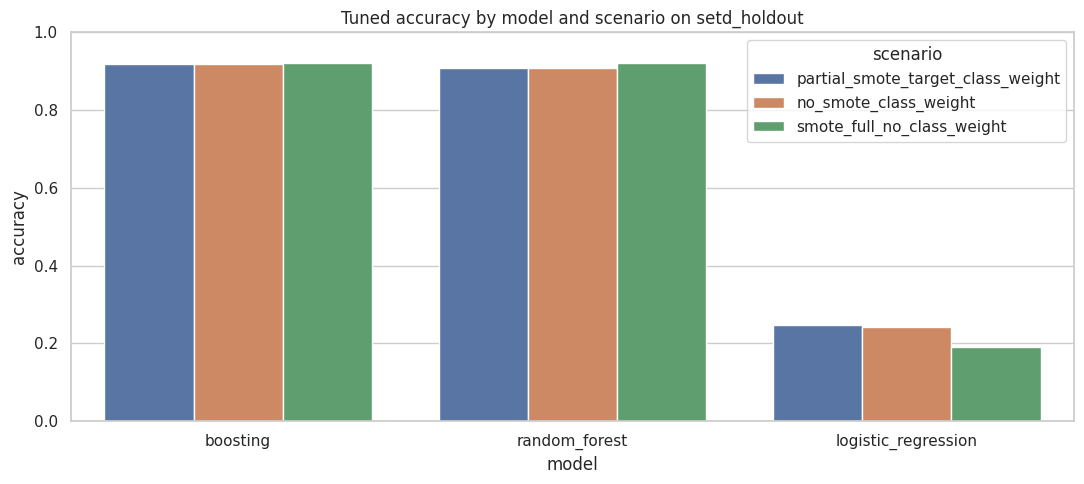

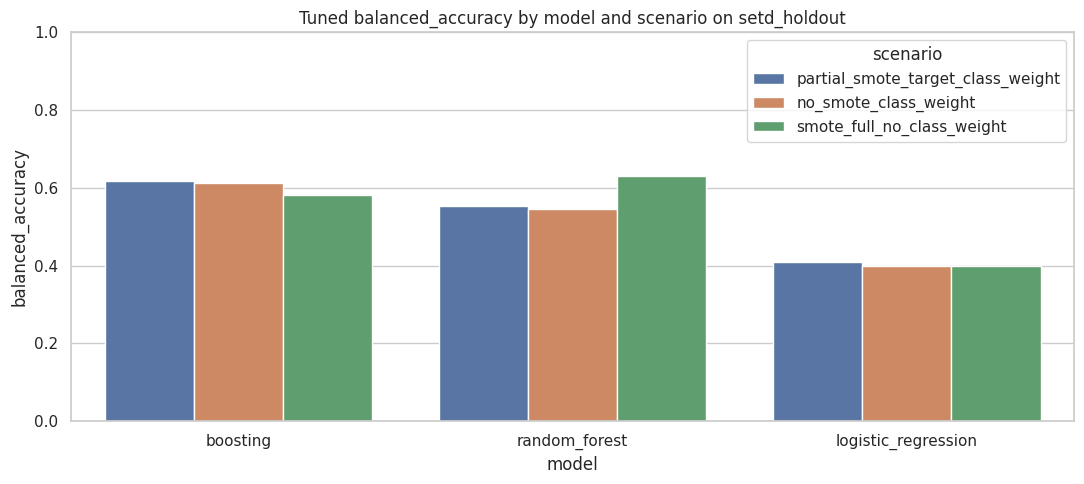

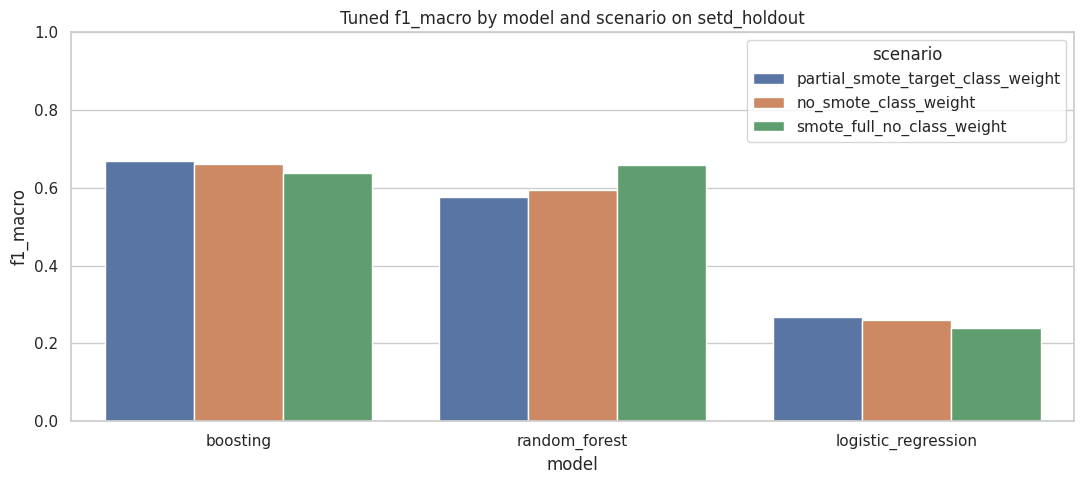

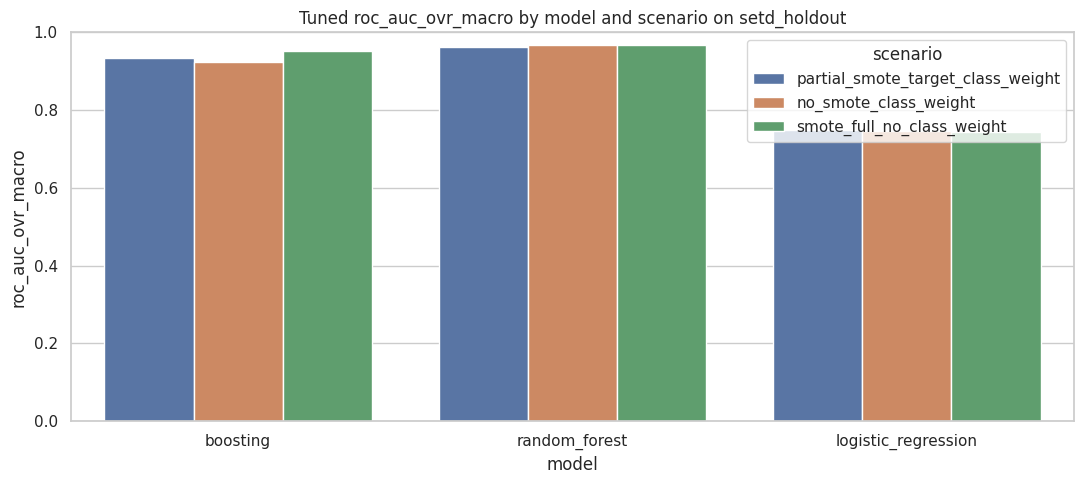

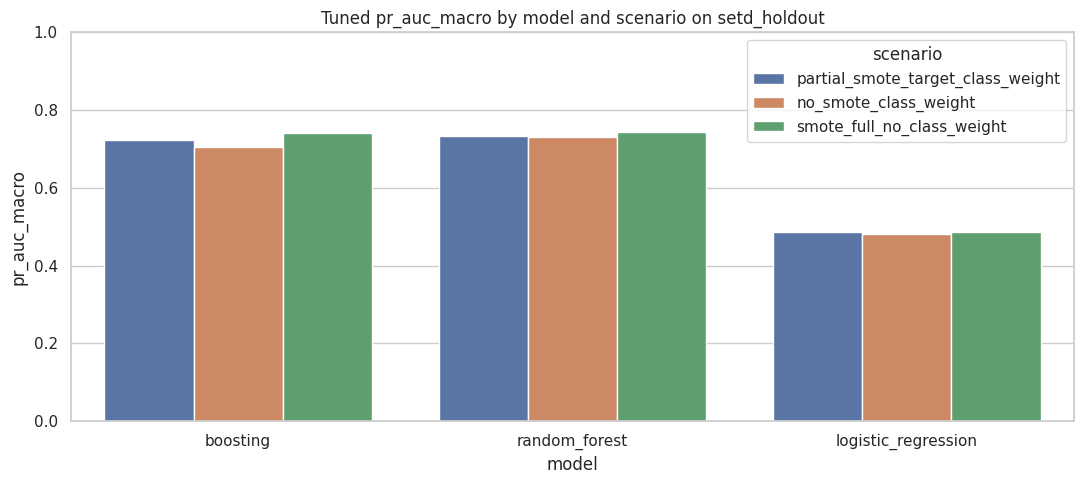

Scenario deltas against no_smote_class_weight baseline:


,model,dataset,scenario_minus_baseline,delta_accuracy,delta_balanced_accuracy,delta_f1_macro,delta_roc_auc_ovr_macro,delta_pr_auc_macro
0,logistic_regression,abc_test,smote_full_no_class_weight-vs-no_smote_class_w...,-0.001786,0.009369,0.000973,0.000483,0.010276
1,logistic_regression,abc_test,partial_smote_target_class_weight-vs-no_smote_...,0.000963,0.003428,0.003066,0.001347,0.011722
2,logistic_regression,setd_holdout,smote_full_no_class_weight-vs-no_smote_class_w...,-0.050224,0.000198,-0.018857,-0.002485,0.003857
3,logistic_regression,setd_holdout,partial_smote_target_class_weight-vs-no_smote_...,0.005393,0.010187,0.007132,0.002310,0.004978
4,random_forest,abc_test,smote_full_no_class_weight-vs-no_smote_class_w...,-0.001115,0.020821,-0.010154,0.001226,0.000563
5,random_forest,abc_test,partial_smote_target_class_weight-vs-no_smote_...,0.000177,0.012161,-0.004013,0.002306,-0.000711
6,random_forest,setd_holdout,smote_full_no_class_weight-vs-no_smote_class_w...,0.011880,0.084800,0.064080,0.000799,0.012405
7,random_forest,setd_holdout,partial_smote_target_class_weight-vs-no_smote_...,0.000980,0.006740,-0.018870,-0.003252,0.002546
8,boosting,abc_test,smote_full_no_class_weight-vs-no_smote_class_w...,0.004167,-0.036070,0.013392,0.001567,-0.000522
9,boosting,abc_test,partial_smote_target_class_weight-vs-no_smote_...,0.000975,-0.006506,0.008328,0.002436,0.003166


Generalization gap (SetD holdout - ABC test):


,model,scenario,gap_accuracy,gap_balanced_accuracy,gap_f1_macro,gap_roc_auc_ovr_macro,gap_pr_auc_macro
0,logistic_regression,smote_full_no_class_weight,-0.543985,-0.337996,-0.174791,-0.136937,-0.073166
1,logistic_regression,partial_smote_target_class_weight,-0.491117,-0.322066,-0.150894,-0.133005,-0.073491
2,logistic_regression,no_smote_class_weight,-0.495547,-0.328825,-0.154961,-0.133968,-0.066747
3,random_forest,smote_full_no_class_weight,-0.054251,-0.261639,-0.178027,-0.018499,-0.158075
4,random_forest,partial_smote_target_class_weight,-0.066442,-0.331038,-0.267118,-0.023631,-0.166659
5,random_forest,no_smote_class_weight,-0.067245,-0.325617,-0.252261,-0.018073,-0.169917
6,boosting,smote_full_no_class_weight,-0.061750,-0.283302,-0.231678,-0.034822,-0.175200
7,boosting,partial_smote_target_class_weight,-0.060107,-0.275693,-0.196814,-0.055478,-0.196451
8,boosting,no_smote_class_weight,-0.059363,-0.286684,-0.194832,-0.061585,-0.212217


Per-class precision/recall/f1 snapshot:


,model,scenario,dataset,class_name,precision,recall,f1,support
0,logistic_regression,smote_full_no_class_weight,abc_test,DDoS attack,0.045395,0.604956,0.084453,686
1,logistic_regression,smote_full_no_class_weight,abc_test,Normal traffic,0.993630,0.730212,0.841795,74981
2,logistic_regression,smote_full_no_class_weight,abc_test,Suspicious traffic,0.195404,0.874620,0.319440,3286
3,logistic_regression,smote_full_no_class_weight,setd_holdout,DDoS attack,0.323902,0.427340,0.368500,14733
4,logistic_regression,smote_full_no_class_weight,setd_holdout,Normal traffic,0.943643,0.151657,0.261317,394482
5,logistic_regression,smote_full_no_class_weight,setd_holdout,Suspicious traffic,0.049413,0.616803,0.091497,28424
6,logistic_regression,partial_smote_target_class_weight,abc_test,DDoS attack,0.042354,0.572886,0.078876,686
7,logistic_regression,partial_smote_target_class_weight,abc_test,Normal traffic,0.994175,0.732892,0.843769,74981
8,logistic_regression,partial_smote_target_class_weight,abc_test,Suspicious traffic,0.202236,0.886184,0.329319,3286
9,logistic_regression,partial_smote_target_class_weight,setd_holdout,DDoS attack,0.304000,0.422521,0.353593,14733


In [10]:
summary_pivot = final_results_df.pivot_table(
    index=["model", "scenario"],
    columns="dataset",
    values=["accuracy", "balanced_accuracy", "f1_macro", "roc_auc_ovr_macro", "pr_auc_macro"],
    aggfunc="mean",
)
display(summary_pivot)

for ds in ["abc_test", "setd_holdout"]:
    subset = final_results_df[final_results_df["dataset"] == ds].copy()
    for metric in ["accuracy", "balanced_accuracy", "f1_macro", "roc_auc_ovr_macro", "pr_auc_macro"]:
        plt.figure(figsize=(11, 5))
        ax = sns.barplot(
            data=subset,
            x="model",
            y=metric,
            hue="scenario",
            errorbar=None,
        )
        ax.set_ylim(0, 1)
        ax.set_title(f"Tuned {metric} by model and scenario on {ds}")
        plt.tight_layout()
        plt.show()

baseline = "no_smote_class_weight"
delta_rows = []
for model_name in MODEL_NAMES:
    for ds in ["abc_test", "setd_holdout"]:
        base = final_results_df[
            (final_results_df["model"] == model_name)
            & (final_results_df["scenario"] == baseline)
            & (final_results_df["dataset"] == ds)
        ]
        for scenario in ["smote_full_no_class_weight", "partial_smote_target_class_weight"]:
            alt = final_results_df[
                (final_results_df["model"] == model_name)
                & (final_results_df["scenario"] == scenario)
                & (final_results_df["dataset"] == ds)
            ]
            if len(base) == 1 and len(alt) == 1:
                delta_rows.append({
                    "model": model_name,
                    "dataset": ds,
                    "scenario_minus_baseline": f"{scenario}-vs-{baseline}",
                    "delta_accuracy": float(alt.iloc[0]["accuracy"] - base.iloc[0]["accuracy"]),
                    "delta_balanced_accuracy": float(alt.iloc[0]["balanced_accuracy"] - base.iloc[0]["balanced_accuracy"]),
                    "delta_f1_macro": float(alt.iloc[0]["f1_macro"] - base.iloc[0]["f1_macro"]),
                    "delta_roc_auc_ovr_macro": float(alt.iloc[0]["roc_auc_ovr_macro"] - base.iloc[0]["roc_auc_ovr_macro"]),
                    "delta_pr_auc_macro": float(alt.iloc[0]["pr_auc_macro"] - base.iloc[0]["pr_auc_macro"]),
                })

delta_df = pd.DataFrame(delta_rows)
print("Scenario deltas against no_smote_class_weight baseline:")
display(delta_df)

gap_rows = []
for model_name in MODEL_NAMES:
    for scenario in SCENARIOS:
        test_row = final_results_df[
            (final_results_df["model"] == model_name)
            & (final_results_df["scenario"] == scenario)
            & (final_results_df["dataset"] == "abc_test")
        ]
        hold_row = final_results_df[
            (final_results_df["model"] == model_name)
            & (final_results_df["scenario"] == scenario)
            & (final_results_df["dataset"] == "setd_holdout")
        ]
        if len(test_row) == 1 and len(hold_row) == 1:
            gap_rows.append({
                "model": model_name,
                "scenario": scenario,
                "gap_accuracy": float(hold_row.iloc[0]["accuracy"] - test_row.iloc[0]["accuracy"]),
                "gap_balanced_accuracy": float(hold_row.iloc[0]["balanced_accuracy"] - test_row.iloc[0]["balanced_accuracy"]),
                "gap_f1_macro": float(hold_row.iloc[0]["f1_macro"] - test_row.iloc[0]["f1_macro"]),
                "gap_roc_auc_ovr_macro": float(hold_row.iloc[0]["roc_auc_ovr_macro"] - test_row.iloc[0]["roc_auc_ovr_macro"]),
                "gap_pr_auc_macro": float(hold_row.iloc[0]["pr_auc_macro"] - test_row.iloc[0]["pr_auc_macro"]),
            })

generalization_gap_df = pd.DataFrame(gap_rows)
print("Generalization gap (SetD holdout - ABC test):")
display(generalization_gap_df)

print("Per-class precision/recall/f1 snapshot:")
display(per_class_metrics_df.head(18))

Best tuned run on ABC test:


,model,scenario,dataset,accuracy,balanced_accuracy,f1_macro,roc_auc_ovr_macro,pr_auc_macro,fit_time_sec,best_params,target_class,target_ratio_before,target_ratio_after,partial_smote_applied,predict_time_sec
0,boosting,smote_full_no_class_weight,abc_test,0.982509,0.864253,0.870257,0.987728,0.915987,9.71966,"{""learning_rate"": 0.1, ""n_estimators"": 400, ""n...",DDoS attack,0.008682,0.008682,False,7.961867


Best tuned run on SetD holdout:


,model,scenario,dataset,accuracy,balanced_accuracy,f1_macro,roc_auc_ovr_macro,pr_auc_macro,fit_time_sec,best_params,target_class,target_ratio_before,target_ratio_after,partial_smote_applied,predict_time_sec
9,boosting,partial_smote_target_class_weight,setd_holdout,0.91921,0.618125,0.668379,0.933118,0.723224,4.876885,"{""learning_rate"": 0.1, ""n_estimators"": 400, ""n...",DDoS attack,0.008682,0.131428,True,7.923606


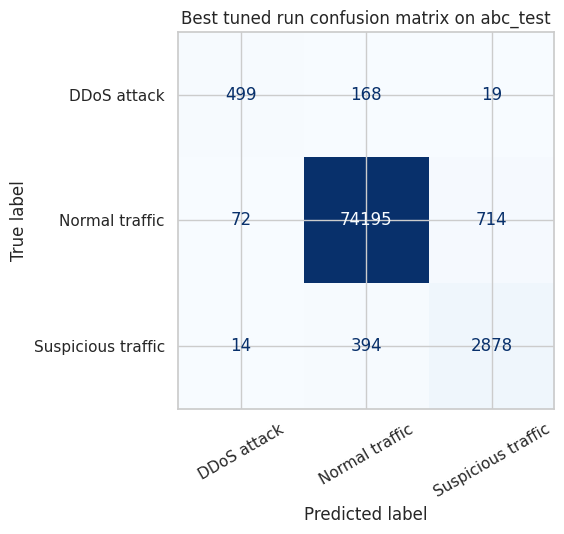

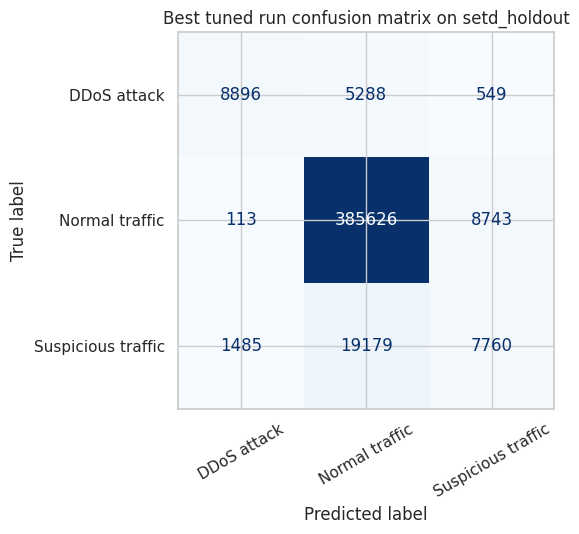

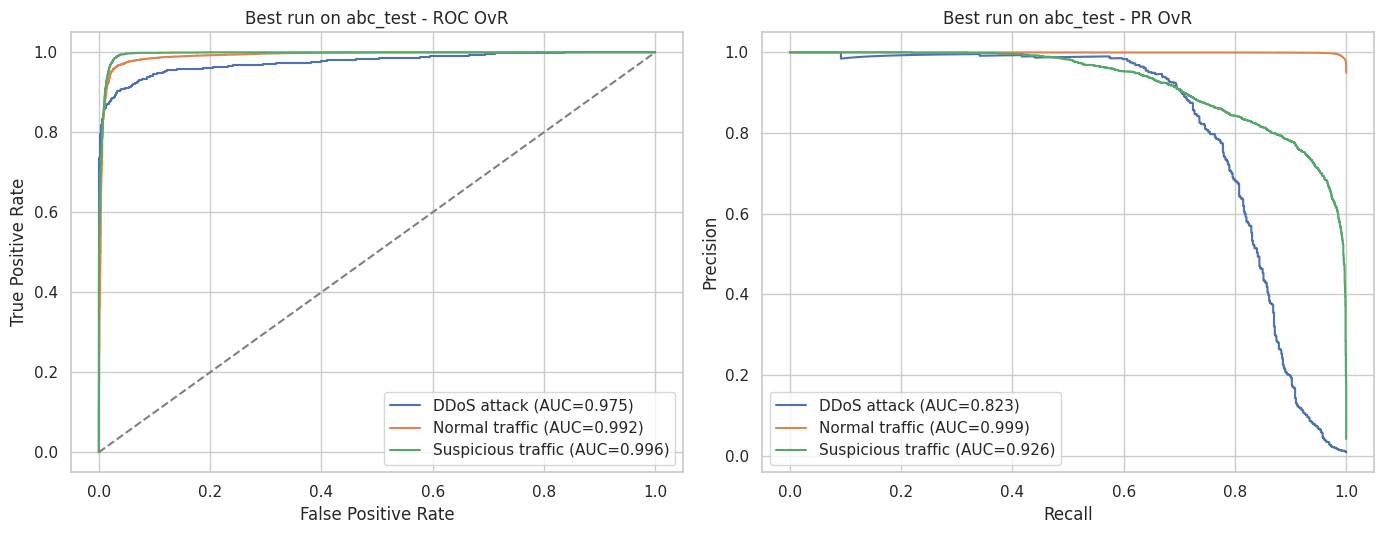

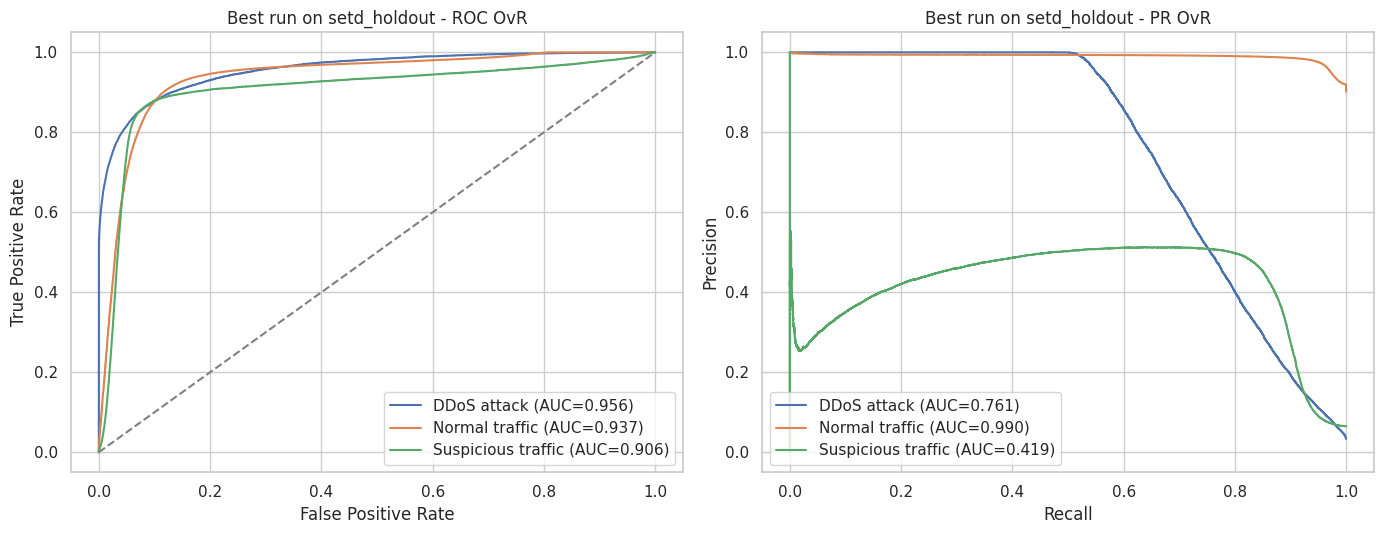

In [11]:
def best_run_for_dataset(results: pd.DataFrame, dataset_name: str):
    sub = results[results["dataset"] == dataset_name].copy()
    sub = sub.sort_values(["f1_macro", "balanced_accuracy", "accuracy"], ascending=False)
    return sub.iloc[0]

best_abc = best_run_for_dataset(final_results_df, "abc_test")
best_holdout = best_run_for_dataset(final_results_df, "setd_holdout")

print("Best tuned run on ABC test:")
display(best_abc.to_frame().T)
print("Best tuned run on SetD holdout:")
display(best_holdout.to_frame().T)

for ds_name, best_row in [
    ("abc_test", best_abc),
    ("setd_holdout", best_holdout),
]:
    key = (best_row["model"], best_row["scenario"])
    payload = final_predictions[key][ds_name]
    y_true = payload["y_true"]
    y_pred = payload["y_pred"]

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        ax=ax,
        cmap="Blues",
        xticks_rotation=30,
        colorbar=False,
        labels=CLASS_LABELS_TRAIN,
    )
    ax.set_title(f"Best tuned run confusion matrix on {ds_name}")
    plt.tight_layout()
    plt.show()

def plot_multiclass_roc_pr(y_true, y_proba, class_labels, title_prefix: str):
    y_bin = label_binarize(y_true, classes=class_labels)
    if y_bin.ndim == 1:
        y_bin = y_bin.reshape(-1, 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    roc_any = False
    pr_any = False

    for idx, class_name in enumerate(class_labels):
        if idx >= y_bin.shape[1]:
            continue
        y_class = y_bin[:, idx]
        if y_class.sum() == 0 or y_class.sum() == len(y_class):
            continue

        fpr, tpr, _ = roc_curve(y_class, y_proba[:, idx])
        precision, recall, _ = precision_recall_curve(y_class, y_proba[:, idx])
        roc_auc_val = auc(fpr, tpr)
        pr_auc_val = auc(recall, precision)

        axes[0].plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc_val:.3f})")
        axes[1].plot(recall, precision, label=f"{class_name} (AUC={pr_auc_val:.3f})")
        roc_any = True
        pr_any = True

    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{title_prefix} - ROC OvR")
    axes[0].legend(loc="lower right")

    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title(f"{title_prefix} - PR OvR")
    axes[1].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

    if not roc_any or not pr_any:
        print(f"No valid ROC/PR curves could be plotted for {title_prefix}.")

for ds_name, best_row in [
    ("abc_test", best_abc),
    ("setd_holdout", best_holdout),
]:
    key = (best_row["model"], best_row["scenario"])
    payload = final_predictions[key][ds_name]
    plot_multiclass_roc_pr(
        y_true=payload["y_true"],
        y_proba=payload["y_proba"],
        class_labels=CLASS_LABELS_TRAIN,
        title_prefix=f"Best run on {ds_name}",
    )

In [12]:
# Persist artifacts
tuning_path = OUT_DIR / "tuning_candidates_validation.csv"
best_params_path = OUT_DIR / "best_params_by_model_scenario.json"
final_results_path = OUT_DIR / "final_tuned_comparison_results.csv"
delta_path = OUT_DIR / "final_tuned_scenario_delta.csv"
summary_path = OUT_DIR / "final_tuned_summary_pivot.csv"
per_class_path = OUT_DIR / "final_tuned_per_class_metrics.csv"
roc_pr_path = OUT_DIR / "final_tuned_roc_pr_per_class.csv"
gap_path = OUT_DIR / "final_tuned_generalization_gap.csv"
config_path = OUT_DIR / "tuned_experiment_config.json"

tuning_results_df.to_csv(tuning_path, index=False)
final_results_df.to_csv(final_results_path, index=False)
delta_df.to_csv(delta_path, index=False)
summary_pivot.reset_index().to_csv(summary_path, index=False)
per_class_metrics_df.to_csv(per_class_path, index=False)
roc_pr_df.to_csv(roc_pr_path, index=False)
generalization_gap_df.to_csv(gap_path, index=False)

best_params_dump = {f"{k[0]}::{k[1]}": v for k, v in best_params_map.items()}
with open(best_params_path, "w", encoding="utf-8") as f:
    json.dump(best_params_dump, f, indent=2)

config_payload = {
    "train_recordings": TRAIN_RECORDINGS,
    "holdout_recording": HOLDOUT_RECORDING,
    "target": TARGET_COL,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
    "val_size": VAL_SIZE,
    "models": MODEL_NAMES,
    "scenarios": SCENARIOS,
    "tuning_primary_metric": TUNING_PRIMARY_METRIC,
    "boosting_backend": BOOSTING_BACKEND,
    "partial_smote_target_class": PARTIAL_SMOTE_TARGET_CLASS,
    "partial_smote_target_ratio": PARTIAL_SMOTE_TARGET_RATIO,
}
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_payload, f, indent=2)

print("Saved artifacts:")
print(f"- {tuning_path}")
print(f"- {best_params_path}")
print(f"- {final_results_path}")
print(f"- {delta_path}")
print(f"- {summary_path}")
print(f"- {per_class_path}")
print(f"- {roc_pr_path}")
print(f"- {gap_path}")
print(f"- {config_path}")

Saved artifacts:
- ddos-detection/model_comparison_tuned_setABC_holdoutD/tuning_candidates_validation.csv
- ddos-detection/model_comparison_tuned_setABC_holdoutD/best_params_by_model_scenario.json
- ddos-detection/model_comparison_tuned_setABC_holdoutD/final_tuned_comparison_results.csv
- ddos-detection/model_comparison_tuned_setABC_holdoutD/final_tuned_scenario_delta.csv
- ddos-detection/model_comparison_tuned_setABC_holdoutD/final_tuned_summary_pivot.csv
- ddos-detection/model_comparison_tuned_setABC_holdoutD/final_tuned_per_class_metrics.csv
- ddos-detection/model_comparison_tuned_setABC_holdoutD/final_tuned_roc_pr_per_class.csv
- ddos-detection/model_comparison_tuned_setABC_holdoutD/final_tuned_generalization_gap.csv
- ddos-detection/model_comparison_tuned_setABC_holdoutD/tuned_experiment_config.json


## Notes

- Tuning az ABC train -> validation vonalon tortenik.
- Vegso meres a kivalasztott parameterekkel: ABC test es SetD holdout.
- Scenario-k: full SMOTE (class_weight nelkul), partial SMOTE csak DDoS attack osztalyra + class_weight, illetve no SMOTE + class_weight.
- Partial SMOTE csak akkor aktiv, ha a DDoS attack osztaly aranya kisebb mint 0.15 a train adaton.
- ROC/PR gorbek multiclass OvR modban keszulnek a legjobb futasokra.

In [ ]:
# Leakage diagnostic: exact overlap and duplicate pressure across ABC random split
def _hash_rows(df: pd.DataFrame) -> pd.Series:
    return pd.util.hash_pandas_object(df.reset_index(drop=True), index=False)

diag_train = abc_train.copy()
diag_test = abc_test.copy()

diag_train_X, _ = split_xy(diag_train)
diag_test_X, _ = split_xy(diag_test)

train_hash = _hash_rows(diag_train_X)
test_hash = _hash_rows(diag_test_X)

train_hash_set = set(train_hash.values.tolist())
test_hash_set = set(test_hash.values.tolist())
shared_hash_count = len(train_hash_set & test_hash_set)

dup_train_ratio = float(train_hash.duplicated().mean())
dup_test_ratio = float(test_hash.duplicated().mean())

print("Leakage diagnostic summary")
print("- Train size:", len(diag_train_X))
print("- Test size:", len(diag_test_X))
print("- Shared exact feature rows (hash overlap):", shared_hash_count)
print("- Shared ratio vs unique train hashes:", shared_hash_count / max(1, len(train_hash_set)))
print("- Shared ratio vs unique test hashes:", shared_hash_count / max(1, len(test_hash_set)))
print("- Duplicate ratio in train features:", dup_train_ratio)
print("- Duplicate ratio in test features:", dup_test_ratio)

print("\nTop suspicious single-feature target separability probes:")
for col in ["detect_count", "comp_detect_count_max", "packet_speed", "comp_source_ip_count_max"]:
    if col in abc_all.columns:
        grp = abc_all.groupby(TARGET_COL)[col].describe()[["mean", "std", "min", "max"]]
        print(f"\nFeature: {col}")
        display(grp)